In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

# images sit in question/a1images/
IMG_DIR  = os.path.normpath(os.path.join(os.getcwd(), '..', 'question', 'a1images'))
SAVE_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
# derivative of Gaussian: multiply the Gaussian by -x/sigma^2 to get dG/dx
# this gives a smooth edge detector — Gaussian first, then differentiate
# normalize by sum of absolute values so both kernels have the same scale
def dog_kernels(size, sigma):
    half = size // 2
    ax   = np.arange(-half, half + 1, dtype=np.float64)
    X, Y = np.meshgrid(ax, ax)
    G    = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    dGdx = (-X / sigma**2) * G
    dGdy = (-Y / sigma**2) * G
    return dGdx / np.abs(dGdx).sum(), dGdy / np.abs(dGdy).sum()

In [3]:
# print 5x5 versions — dG/dx should be antisymmetric left-right,
# dG/dy antisymmetric top-bottom; also grab 51x51 for the surface plot
Kx5, Ky5   = dog_kernels(5, 2)
Kx51, Ky51 = dog_kernels(51, 2)

print('dG/dx  5x5:')
print(np.round(Kx5, 5))
print('\ndG/dy  5x5:')
print(np.round(Ky5, 5))

dG/dx  5x5:
[[ 0.04413  0.0321  -0.      -0.0321  -0.04413]
 [ 0.06421  0.04671 -0.      -0.04671 -0.06421]
 [ 0.07276  0.05293 -0.      -0.05293 -0.07276]
 [ 0.06421  0.04671 -0.      -0.04671 -0.06421]
 [ 0.04413  0.0321  -0.      -0.0321  -0.04413]]

dG/dy  5x5:
[[ 0.04413  0.06421  0.07276  0.06421  0.04413]
 [ 0.0321   0.04671  0.05293  0.04671  0.0321 ]
 [-0.      -0.      -0.      -0.      -0.     ]
 [-0.0321  -0.04671 -0.05293 -0.04671 -0.0321 ]
 [-0.04413 -0.06421 -0.07276 -0.06421 -0.04413]]


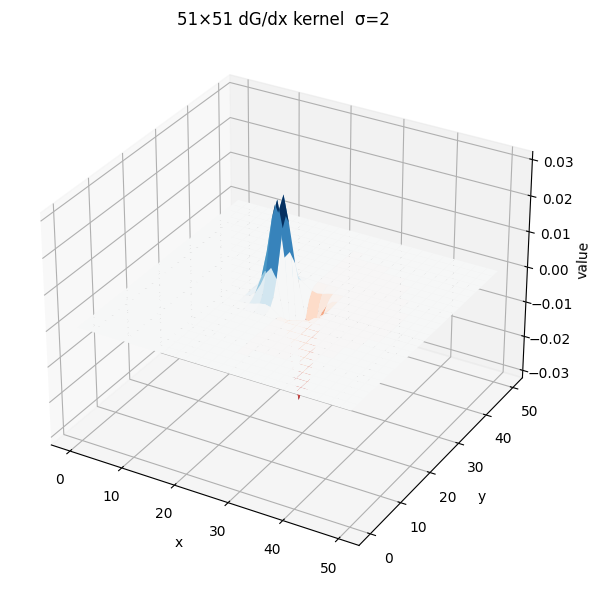

In [4]:
# 3D surface of dG/dx — RdBu colormap shows the positive/negative lobes clearly
x    = np.arange(51)
X, Y = np.meshgrid(x, x)

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Kx51, cmap='RdBu', linewidth=0)
ax.set_title('51×51 dG/dx kernel  σ=2')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('value')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q6_dog_surface.png'), dpi=150)
plt.show()

In [5]:
# convolve shells.tif with our DoG kernels to get x and y gradients
# then do the same with Sobel so we can compare the two approaches
img   = cv2.imread(os.path.join(IMG_DIR, 'shells.tif'), cv2.IMREAD_GRAYSCALE)
img_f = img.astype(np.float32)

grad_x_dog = cv2.filter2D(img_f, cv2.CV_32F, Kx5.astype(np.float32))
grad_y_dog = cv2.filter2D(img_f, cv2.CV_32F, Ky5.astype(np.float32))

sobel_x = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=5)

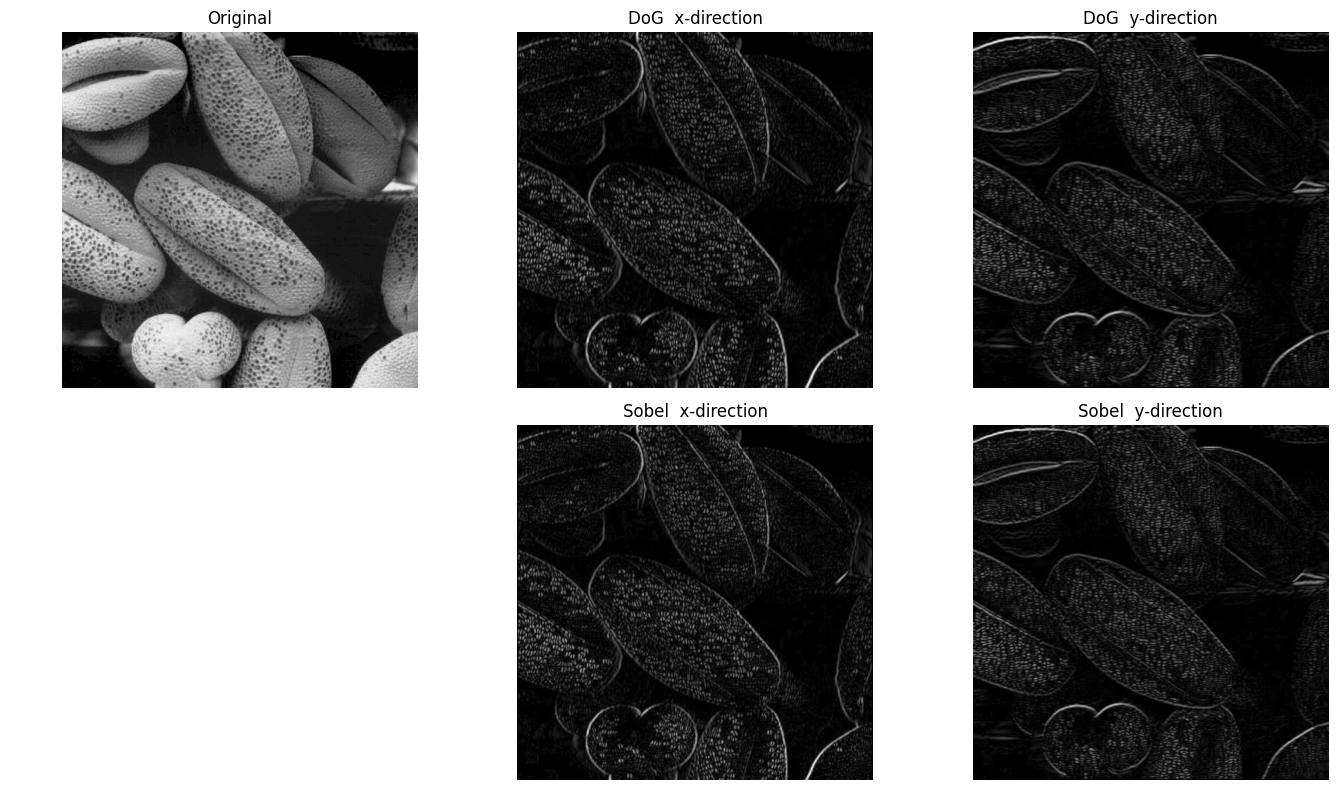

In [6]:
# scale each response to [0, 255] just so they display nicely
# top row: DoG gradients; bottom row: Sobel for comparison
def norm_disp(arr):
    a = np.abs(arr)
    return (a / a.max() * 255).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(norm_disp(grad_x_dog), cmap='gray')
axes[0, 1].set_title('DoG  x-direction')
axes[0, 1].axis('off')

axes[0, 2].imshow(norm_disp(grad_y_dog), cmap='gray')
axes[0, 2].set_title('DoG  y-direction')
axes[0, 2].axis('off')

axes[1, 0].axis('off')

axes[1, 1].imshow(norm_disp(sobel_x), cmap='gray')
axes[1, 1].set_title('Sobel  x-direction')
axes[1, 1].axis('off')

axes[1, 2].imshow(norm_disp(sobel_y), cmap='gray')
axes[1, 2].set_title('Sobel  y-direction')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q6_gradients.png'), dpi=150)
plt.show()